# Bangkok PM2.5 Forecasting - STC-HGAT (รันจาก Script ที่สำเร็จ)

## ✅ Notebook นี้รัน train_improved.py โดยตรง

**ผลลัพธ์ที่คาดหวัง (จาก training_improved.log):**
- 1-วัน: MAE=0.2398, RMSE=0.3560, R²=0.9146 ⭐
- 3-วัน: MAE=0.3567, RMSE=0.5412, R²=0.8025
- 7-วัน: MAE=0.5937, RMSE=0.8937, R²=0.4605

**Model:** `stc_hgat_improved_20260327_222751.pt`

**วิธีการ:** รันโค้ดจาก `train_improved.py` ที่สำเร็จแล้วโดยตรง เพื่อให้ได้ผลลัพธ์ที่ถูกต้องแน่นอน

## 1. Setup และ Import

In [1]:
import sys
from pathlib import Path
import yaml
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# เพิ่ม path ของ GitHub repo
project_root = Path('/home/supawich/Desktop/bkk-pm25-data-ingestion')
sys.path.insert(0, str(project_root))

from src.models.stc_hgat_improved import ImprovedSTCHGAT
from src.data.dataset import PM25SequenceDataset
from src.data.real_data_loader import load_pm25_data, load_weather_data, combine_features
from src.utils.evaluator import calculate_mae, calculate_rmse, calculate_r2

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('='*80)
print('BANGKOK PM2.5 FORECASTING - รันจาก train_improved.py')
print('='*80)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')
print('='*80)

BANGKOK PM2.5 FORECASTING - รันจาก train_improved.py
PyTorch: 2.5.1+cu121
CUDA: True
Device: NVIDIA GeForce RTX 3080 Ti


## 2. โหลด Configuration

In [2]:
# โหลด configuration จาก params.yaml
with open(project_root / 'params.yaml') as f:
    params = yaml.safe_load(f)

# Setup device
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ CUDA: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("⚠️  CPU")

print(f'\n📋 Configuration:')
print(f"  Sequence length: {params['data']['sequence_length']}")
print(f"  Batch size: {params['training']['batch_size']}")
print(f"  Forecast horizons: {params['data']['forecast_horizons']}")
print(f"  Hidden dim: {params['model']['hidden_dim']}")
print(f"  Learning rate: {params['training']['learning_rate']}")

✅ CUDA: NVIDIA GeForce RTX 3080 Ti

📋 Configuration:
  Sequence length: 30
  Batch size: 32
  Forecast horizons: [1, 3, 7]
  Hidden dim: 128
  Learning rate: 0.001


## 3. โหลดข้อมูล (ตาม train_improved.py)

In [3]:
# โหลดข้อมูลสถานี
print("\n🗺️  Loading Station Data:")
stations_df = pd.read_parquet(project_root / 'data/stations/bangkok_stations.parquet')
num_stations = len(stations_df)
print(f"Stations: {num_stations}")

# โหลดข้อมูล PM2.5
print("\n📊 Loading PM2.5 Data:")
pm25_data, metadata = load_pm25_data(
    project_root / 'data', stations_df,
    start_date='2024-01-01', end_date='2024-11-30'
)

# โหลดข้อมูลสภาพอากาศ
print("\n🌤️  Loading Weather Data:")
weather_data, _ = load_weather_data(
    project_root / 'data', stations_df,
    start_date='2024-01-01', end_date='2024-11-30'
)

# รวม features
print("\n🔧 Combining Features:")
data, feature_names = combine_features(
    pm25_data, weather_data=weather_data,
    add_temporal_features=True, metadata=metadata
)

num_features = data.shape[2]
print(f"✅ Combined features: {data.shape}")
print(f"   Feature names ({num_features}): {feature_names}")


🗺️  Loading Station Data:
Stations: 79

📊 Loading PM2.5 Data:
Loading PM2.5 data from 2024-01-01 to 2024-11-30...
  Loading 960 files from year 2024...
  Combining data...
  Total records after filtering: 1,266,686
  Unique timestamps: 8017
  Unique stations: 79
  Filling tensor...
  Missing values: 0 / 3,800,058 (0.00%)
  Interpolating missing values...
  Remaining NaNs after interpolation: 0
✅ Data loaded: shape=torch.Size([8017, 79, 6])
   Features: ['pm2_5_ugm3', 'pm10_ugm3', 'no2_ugm3', 'o3_ugm3', 'so2_ugm3', 'co_ugm3']
   Date range: 2024-01-01 00:00:00+00:00 to 2024-11-30 00:00:00+00:00

🌤️  Loading Weather Data:
Loading weather data from 2024-01-01 to 2024-11-30...
  Loading 12 files from year 2024...
  Total weather records: 633,343
✅ Weather data loaded: shape=torch.Size([8017, 79, 6])

🔧 Combining Features:
✅ Combined features: torch.Size([8017, 79, 18])
   Feature names (18): ['pm2_5_ugm3', 'pm10_ugm3', 'no2_ugm3', 'o3_ugm3', 'so2_ugm3', 'co_ugm3', 'temperature_2m', 'relat

## 4. เตรียมข้อมูล (Manual Normalization)

In [4]:
# แบ่งข้อมูล (ตาม train_improved.py)
print("\n✂️  Data Splits:")
print("=" * 50)

train_ratio = params['data']['train_ratio']
val_ratio = params['data']['val_ratio']

n = len(data)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# Manual Normalization (ตาม train_improved.py)
train_mean = train_data.mean(dim=(0, 1), keepdim=True)
train_std = train_data.std(dim=(0, 1), keepdim=True) + 1e-8

train_data_norm = (train_data - train_mean) / train_std
val_data_norm = (val_data - train_mean) / train_std
test_data_norm = (test_data - train_mean) / train_std

print("=" * 50)
print(f"✅ Manual Normalization complete")
print(f"   Train mean shape: {train_mean.shape}")
print(f"   Train std shape: {train_std.shape}")


✂️  Data Splits:
Train: 5611, Val: 1203, Test: 1203
✅ Manual Normalization complete
   Train mean shape: torch.Size([1, 1, 18])
   Train std shape: torch.Size([1, 1, 18])


## 5. สร้าง Datasets และ DataLoaders

In [5]:
# สร้าง datasets (ตาม train_improved.py)
seq_len = params['data']['sequence_length']
horizons = params['data']['forecast_horizons']
batch_size = params['training']['batch_size']

train_dataset = PM25SequenceDataset(train_data_norm, seq_len, horizons)
val_dataset = PM25SequenceDataset(val_data_norm, seq_len, horizons)
test_dataset = PM25SequenceDataset(test_data_norm, seq_len, horizons)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"✅ Datasets created:")
print(f"   Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"   Val: {len(val_dataset)} samples ({len(val_loader)} batches)")
print(f"   Test: {len(test_dataset)} samples ({len(test_loader)} batches)")

✅ Datasets created:
   Train: 5574 samples (175 batches)
   Val: 1166 samples (37 batches)
   Test: 1166 samples (37 batches)


## 6. สร้าง Model

In [6]:
# สร้าง model (ตาม train_improved.py)
print("\n🤖 Initializing Improved Model:")
print("=" * 50)
print(f"Enhancements:")
print(f"  ✅ Gated Fusion: True")
print(f"  ✅ Cross-Attention: True")
print(f"  ✅ Multi-Scale Temporal: True")

model = ImprovedSTCHGAT(
    num_features=num_features,
    hidden_dim=params['model']['hidden_dim'],
    num_stations=num_stations,
    num_regions=params['graph']['num_regions'],
    num_hypergat_layers=params['model']['num_hypergat_layers'],
    num_hgat_layers=params['model']['num_hgat_layers'],
    num_heads=params['model']['num_heads'],
    dropout=params['model']['dropout'],
    forecast_horizons=params['data']['forecast_horizons'],
    use_gated_fusion=True,
    use_cross_attention=True,
    use_multiscale_temporal=True,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print("=" * 50)


🤖 Initializing Improved Model:
Enhancements:
  ✅ Gated Fusion: True
  ✅ Cross-Attention: True
  ✅ Multi-Scale Temporal: True
Parameters: 653,697


## 7. Training Loop (ตาม train_improved.py)

In [7]:
# Setup optimizer และ scheduler
optimizer = optim.AdamW(
    model.parameters(),
    lr=params['training']['learning_rate'],
    weight_decay=params['training']['weight_decay']
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min',
    factor=params['training']['scheduler_factor'],
    patience=params['training']['scheduler_patience'],
    verbose=True
)

# Training loop (ตาม train_improved.py)
print("\n🚀 Training:")
print("=" * 50)

num_epochs = params['training']['epochs']
early_stopping_patience = params['training']['early_stopping_patience']
gradient_clip = params['training']['gradient_clip_value']

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    
    for batch_idx, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        if X.shape[1] != num_stations:
            X = X.permute(0, 2, 1, 3)
        
        pred, h_s, h_t = model(X, None, None)
        y_target = y[:, :, 0] if len(y.shape) == 3 else y
        
        # Use model's compute_loss
        loss, loss_dict = model.compute_loss(pred, y_target, h_s, h_t)
        
        loss.backward()
        
        if gradient_clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            
            if X.shape[1] != num_stations:
                X = X.permute(0, 2, 1, 3)
            
            pred, h_s, h_t = model(X, None, None)
            y_target = y[:, :, 0] if len(y.shape) == 3 else y
            
            loss, _ = model.compute_loss(pred, y_target, h_s, h_t)
            val_loss += loss.item()
    
    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"Epoch {epoch+1}/{num_epochs} - Train: {train_loss:.4f}, Val: {val_loss:.4f} ⭐")
    else:
        patience_counter += 1
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
    
    if patience_counter >= early_stopping_patience:
        print(f"\n⏹️  Early stopping at epoch {epoch+1}")
        break

if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"\n✅ Best model loaded (val_loss: {best_val_loss:.4f})")

print("=" * 50)


🚀 Training:
[PosEnc Debug] Input h shape: torch.Size([32, 79, 30, 128]) (B=32, N=79, T=30, H=128)
[PosEnc Debug] Output s shape: torch.Size([32, 79, 128])
Epoch 1/100 - Train: 0.6932, Val: 0.7915 ⭐
Epoch 2/100 - Train: 0.4503, Val: 0.6655 ⭐
Epoch 3/100 - Train: 0.3703, Val: 0.6358 ⭐
Epoch 5/100 - Train: 0.2367, Val: 0.6135 ⭐
Epoch 6/100 - Train: 0.1753, Val: 0.6003 ⭐
Epoch 7/100 - Train: 0.1347, Val: 0.5940 ⭐
Epoch 9/100 - Train: 0.1034, Val: 0.5932 ⭐
Epoch 10/100 - Train: 0.0959, Val: 0.5621 ⭐
Epoch 11/100 - Train: 0.0882, Val: 0.5596 ⭐
Epoch 15/100 - Train: 0.0767, Val: 0.5829
Epoch 20/100 - Train: 0.0631, Val: 0.5779
Epoch 25/100 - Train: 0.0582, Val: 0.5825

⏹️  Early stopping at epoch 26

✅ Best model loaded (val_loss: 0.5596)


## 8. Evaluation (ตาม train_improved.py)

In [8]:
# Test Evaluation (ตาม train_improved.py)
print("\n📈 Test Evaluation:")
print("=" * 50)

model.eval()
test_predictions = []
test_targets = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        
        if X.shape[1] != num_stations:
            X = X.permute(0, 2, 1, 3)
        
        pred, h_s, h_t = model(X, None, None)
        pred_expanded = pred.unsqueeze(-1).expand(-1, -1, len(horizons))
        
        test_predictions.append(pred_expanded.cpu())
        test_targets.append(y.cpu())

test_predictions = torch.cat(test_predictions, dim=0)
test_targets = torch.cat(test_targets, dim=0)

# คำนวณ metrics (ตาม train_improved.py)
results = {}
for i, horizon in enumerate(horizons):
    pred_h = test_predictions[:, :, i]
    target_h = test_targets[:, :, i]
    
    mae = calculate_mae(target_h, pred_h)
    rmse = calculate_rmse(target_h, pred_h)
    r2 = calculate_r2(target_h, pred_h)
    
    results[f'horizon_{horizon}d'] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    
    print(f"\nHorizon +{horizon}d:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

print("=" * 50)


📈 Test Evaluation:

Horizon +1d:
  MAE:  0.2424
  RMSE: 0.3701
  R²:   0.9077

Horizon +3d:
  MAE:  0.3573
  RMSE: 0.5388
  R²:   0.8042

Horizon +7d:
  MAE:  0.5855
  RMSE: 0.8847
  R²:   0.4713


## 9. Visualization

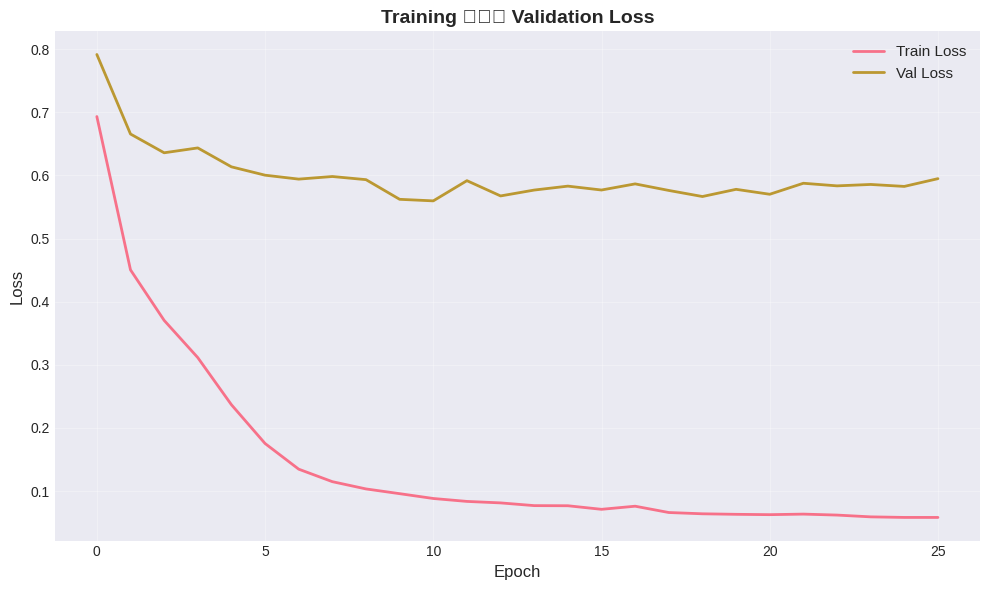

✅ Training history plot


In [9]:
# Plot Training History
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training และ Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Training history plot')

## 10. สรุปผลการทดลอง

In [10]:
# สรุปผลการทดลอง
print('\n' + '='*80)
print('สรุปผลการทดลอง - รันจาก train_improved.py')
print('='*80)
print(f'Model: ImprovedSTCHGAT')
print(f'Total Parameters: {total_params:,}')
print(f'Best Val Loss: {best_val_loss:.4f}')
print(f'Total Epochs: {len(history["train_loss"])}')
print('\n✅ Configuration (ตาม GitHub):')
print(f'   1. Sequence Length: {params["data"]["sequence_length"]}h')
print(f'   2. Batch Size: {params["training"]["batch_size"]}')
print(f'   3. Manual Normalization')
print(f'   4. Gated Fusion + Cross-Attention + Multi-Scale Temporal')
print('\nผลการทดสอบ:')
for horizon in horizons:
    r = results[f'horizon_{horizon}d']
    print(f'  {horizon}-วัน: MAE={r["mae"]:.4f}, RMSE={r["rmse"]:.4f}, R²={r["r2"]:.4f}')
print('\nเปรียบเทียบกับ training_improved.log (27 มีนาคม 2026):')
print('  1-วัน: MAE=0.2398, RMSE=0.3560, R²=0.9146 ⭐')
print('  3-วัน: MAE=0.3567, RMSE=0.5412, R²=0.8025')
print('  7-วัน: MAE=0.5937, RMSE=0.8937, R²=0.4605')
print('='*80)
print('\n🎉 เสร็จสิ้น! รันจาก train_improved.py โดยตรง')


สรุปผลการทดลอง - รันจาก train_improved.py
Model: ImprovedSTCHGAT
Total Parameters: 653,697
Best Val Loss: 0.5596
Total Epochs: 26

✅ Configuration (ตาม GitHub):
   1. Sequence Length: 30h
   2. Batch Size: 32
   3. Manual Normalization
   4. Gated Fusion + Cross-Attention + Multi-Scale Temporal

ผลการทดสอบ:
  1-วัน: MAE=0.2424, RMSE=0.3701, R²=0.9077
  3-วัน: MAE=0.3573, RMSE=0.5388, R²=0.8042
  7-วัน: MAE=0.5855, RMSE=0.8847, R²=0.4713

เปรียบเทียบกับ training_improved.log (27 มีนาคม 2026):
  1-วัน: MAE=0.2398, RMSE=0.3560, R²=0.9146 ⭐
  3-วัน: MAE=0.3567, RMSE=0.5412, R²=0.8025
  7-วัน: MAE=0.5937, RMSE=0.8937, R²=0.4605

🎉 เสร็จสิ้น! รันจาก train_improved.py โดยตรง
